# Jokes clustering and classification using SBERT

Antoine de Chabannes Curton la Palice, Hugo Viana

## Abstract

l'abstract ici

## 1. Introduction

L'intro ici

## 2. Materials and methods

Dependencies

In [1]:
!pip install sentence-transformers
import os
import numpy as np
import pandas as pd
import kagglehub
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

### 2.1. Dataset

Le dataset ici

In [5]:
# Download latest version
path = kagglehub.dataset_download("abhinavmoudgil95/short-jokes")

df = pd.read_csv(os.path.join(path, "shortjokes.csv"))
print(df.head())

Using Colab cache for faster access to the 'short-jokes' dataset.
   ID                                               Joke
0   1  [me narrating a documentary about narrators] "...
1   2  Telling my daughter garlic is good for you. Go...
2   3  I've been going through a really rough period ...
3   4  If I could have dinner with anyone, dead or al...
4   5     Two guys walk into a bar. The third guy ducks.


### 2.2. Jokes embedding

Embedding avec SBERT

In [13]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embeddings = model.encode(
    df["Joke"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

normalized_embeddings = normalize(embeddings, norm='l2')

df["embedding"] = list(embeddings)

df.to_pickle("df_with_embeddings.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7240 [00:00<?, ?it/s]

In [ ]:
print(df.head())

print("Nb jokes :", len(df))
print("Nb embeddings :", len(df["embedding"]))

            ID                                               Joke  \
4510      4511  What do all battered women have in common? The...   
161744  161745  Who invented the North America? TEACHER: Sarah...   
155603  155604  I feel like this election ended up being a goo...   
100593  100594    What do you call a pile of kittens? A Meowntain   
23208    23209  I feel bad for people named John Smith. They p...   

                                                embedding  
4510    [0.073853895, -0.04534559, -0.006082802, 0.009...  
161744  [0.0048997137, 0.032038808, 0.02461662, -0.015...  
155603  [-0.004624908, -0.01984879, 0.07801808, 0.0310...  
100593  [-0.019022545, -0.012466601, -0.018798886, 0.0...  
23208   [-0.13105579, 0.0050398842, 0.11960121, -0.016...  
Nb jokes : 1000
Nb embeddings : 1000


### 2.3. Clustering

1. Choix du nombre de clusters
2. Choix de l'algo (K-Means)
3. Evaluation et Interprétati

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm

df_sample = df.sample(n=1000, random_state=42)
X = np.vstack(df_sample["embedding"].values)

print("Shape de X :", X.shape)

k_values = list(range(2, 14))

inertias = []
silhouette_scores = []

for k in tqdm(k_values, desc="Testing K values"):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

Shape de X : (1000, 384)


Testing K values:   0%|          | 0/12 [00:00<?, ?it/s]

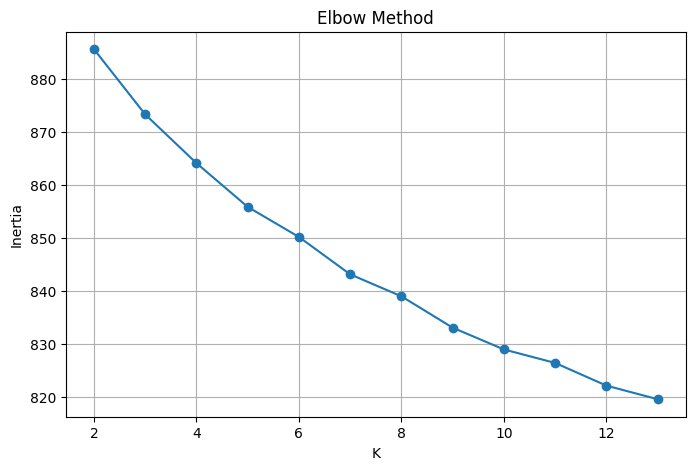

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

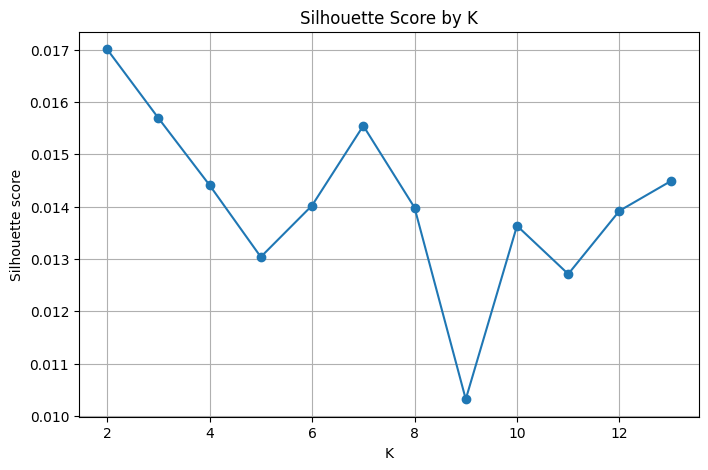

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by K")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


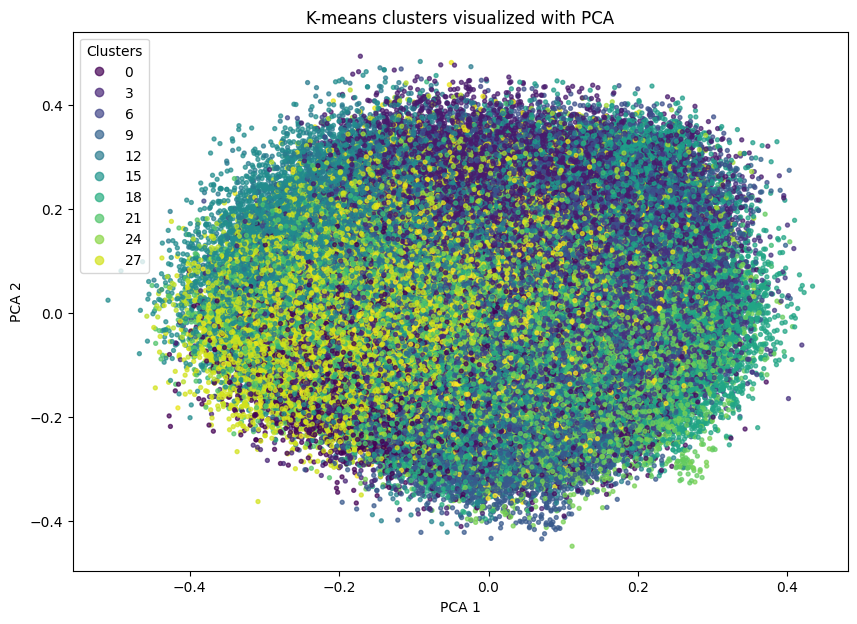

CLUSTER 0 | size = 8420
- After six years of being responsible, I finally went and lost my phone last night. I'm currently using Twitter from the web. LIKE A CAVEMAN.
- FACEBOOK asks me what I'm thinking, TWITTER asks me what I'm doing, FOURSQUARE asks me where I am. Conclusion: Internet is my girlfriend!
- I'm beginning to worry about my obsession with technology. I told my doctor, "I think I'm addicted to Twitter." He replied, "I don't follow you."
- I wonder what people with house phones posted on MySpace today?
- Facebook asks what I'm thinking. Twitter asks what I'm doing. Google asks where I am. The internet has turned into my girlfriend.
CLUSTER 1 | size = 5900
- So, a catholic priest comes on a playground...
- Jesus walks into a bar and says "I'll just have water"
- Teenage Jesus: Hey dad, why you wearing that crucifix? God: It's an idea I have for a public holiday. TJ: Huh? G: It's complicated.
- Someone wrote "Jesus Saves" in the bathroom stall at Walmart. Evandalism.
- A pri

In [20]:
from sklearn.cluster import KMeans
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

K = 30

X = np.vstack(df["embedding"].values)

kmeans = KMeans(
    n_clusters=K,
    init="k-means++",
    random_state=42,
    n_init=10,
)

labels = kmeans.fit_predict(X)

df["cluster"] = labels

X = np.vstack(df["embedding"].values)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df["cluster"],
    s=8,
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-means clusters visualized with PCA")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# for cluster_id in sorted(df["cluster"].unique()):
#     subset = df[df["cluster"] == cluster_id]

#     print(f"CLUSTER {cluster_id} | size = {len(subset)}")

#     sample = subset["Joke"].sample(min(15, len(subset)), random_state=42)

#     for j in sample:
#         print("-", j)

# Compute distances from each joke to its cluster centroid (per-joke distance)
joke_distances = []
for i, embedding in enumerate(X):
    cluster_idx = labels[i]
    dist = np.linalg.norm(embedding - kmeans.cluster_centers_[cluster_idx])
    joke_distances.append((i, df.iloc[i]["Joke"], dist))  # Store (index, joke, distance)

# Sort by distance and pick top 5 per cluster
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    print(f"CLUSTER {cluster_id} | size = {len(subset)}")

    # Extract indices of jokes belonging to this cluster
    cluster_indices = [idx for idx, _, _ in joke_distances if labels[idx] == cluster_id]

    # Create a list of (joke, distance) pairs for this cluster
    cluster_jokes_with_dist = []
    for idx, joke, dist in joke_distances:
        if idx in cluster_indices:  # Only include jokes from this cluster
            cluster_jokes_with_dist.append((joke, dist))

    # Sort by distance and pick top 5 closest jokes
    sorted_cluster_jokes = sorted(cluster_jokes_with_dist, key=lambda x: x[1])
    top_5 = [joke for joke, _ in sorted_cluster_jokes[:min(5, len(cluster_jokes_with_dist))]]

    for j in top_5:
        print("-", j)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 41.4 MB/s eta 0:00:00
Fuzzy Partition Coefficient (FPC) = 0.3333


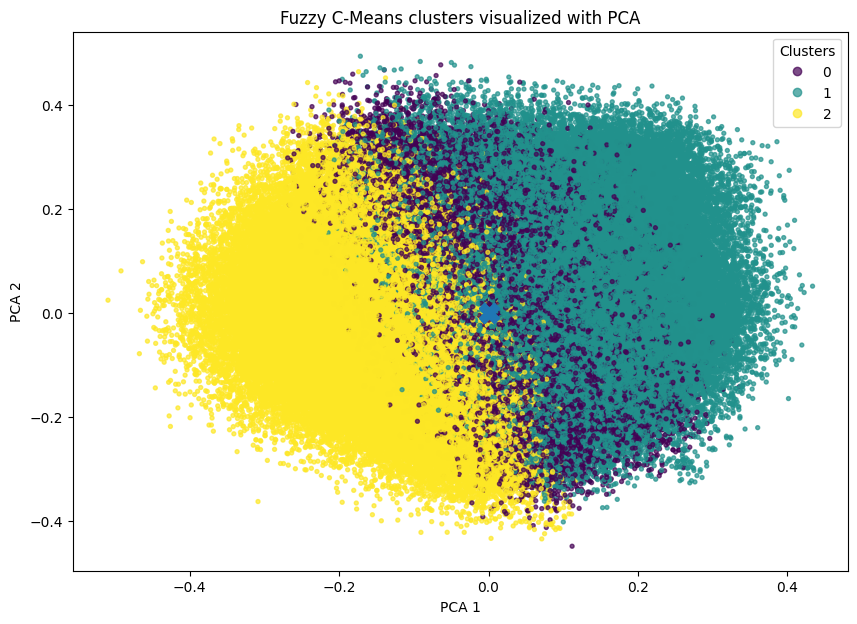

In [15]:
!pip install scikit-fuzzy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import skfuzzy as fuzz

K = 3

# matrice des embeddings
X = np.vstack(df["embedding"].values)   # shape: (n_samples, n_features)

# scikit-fuzzy attend les données sous la forme (n_features, n_samples)
X_fcm = X.T

# Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fcm,
    c=K,              # nombre de clusters
    m=1.5,            # coefficient de flou (classique = 2)
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)

# u : matrice d'appartenance de shape (K, n_samples)
# cluster dur = cluster avec appartenance max
labels = np.argmax(u, axis=0)

df["cluster"] = labels

# stocker aussi les degrés d'appartenance
for i in range(K):
    df[f"membership_cluster_{i}"] = u[i]

print(f"Fuzzy Partition Coefficient (FPC) = {fpc:.4f}")

# PCA pour visualisation
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# projection des centres appris par FCM
centers_2d = pca.transform(cntr)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df["cluster"],
    s=8,
    alpha=0.7
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    s=200,
    marker="X"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Fuzzy C-Means clusters visualized with PCA")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [ ]:
# top most representative jokes
for cluster_id in range(K):
    print(f"\nCLUSTER {cluster_id}")

    subset = df.sort_values(by=f"membership_cluster_{cluster_id}", ascending=False).head(15)

    for _, row in subset.iterrows():
        print(f"- ({row[f'membership_cluster_{cluster_id}']:.3f}) {row['Joke']}")


CLUSTER 0
- (0.125) Doctor: "Your wife is in hospital!"... Me: "...How is she?" Doctor: "I'm afraid she's critical". Me: "Oh, you get used to that...".
- (0.125) My wife said "why do you always treat me like a cunt?" I didn't know what to say, so I just put 2 fingers in her mouth and licked her nose.
- (0.125) I was chatting up this woman. I said, "You're the sort of woman I could introduce to my mum." "Aww," she smiled, "Can you?" I said, "Of course, I'll drive us to the cemetery tomorrow."
- (0.125) "My girlfriend is a feminist", I explained to my grandfather "Well, heck son - nothing wrong with a feminine woman" he replied.
- (0.125) What is the one thing you don't want to hear during sex? Honey, I'm home!
- (0.125) My friend texts "ur" instead of "you're" but puts extra letters in "so" because she's "soooo happy." This is why everyone hates you, Julie.
- (0.125) My girlfriend hates it when I sneak up on her... According to her lawyer, she also hates it when I call her my girlfrien

In [ ]:
!pip install hdbscan
import numpy as np
import hdbscan

X = np.vstack(df["embedding"].values)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,     # taille min d’un cluster
    metric='euclidean'
)

labels = clusterer.fit_predict(X)

df["cluster"] = labels

print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", sum(labels == -1))

Number of clusters: 0
Noise points: 1000


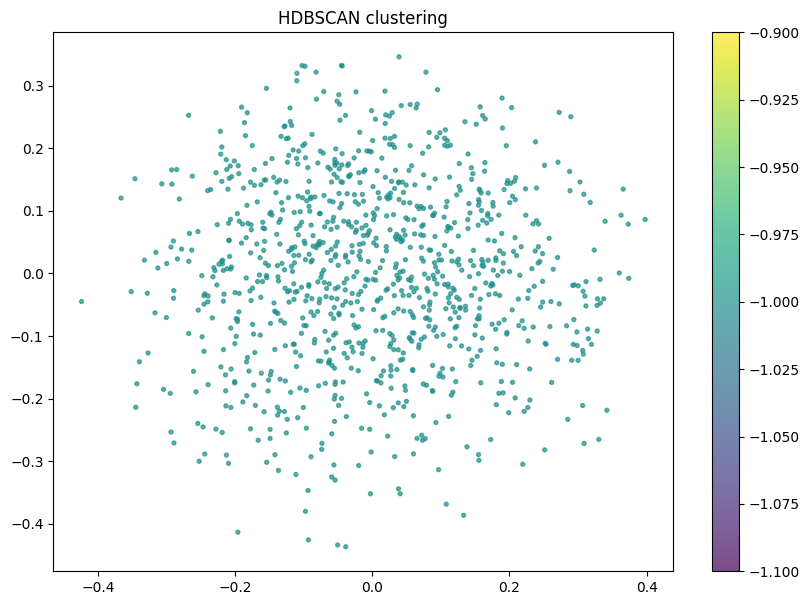

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df["cluster"],
    s=8,
    alpha=0.7
)

plt.title("HDBSCAN clustering")
plt.colorbar(scatter)
plt.show()

In [ ]:
for cluster_id in sorted(set(labels)):
    subset = df[df["cluster"] == cluster_id]

    print(f"\nCLUSTER {cluster_id} | size = {len(subset)}")

    sample = subset["Joke"].sample(min(10, len(subset)), random_state=42)

    for j in sample:
        print("-", j)


CLUSTER -1 | size = 1000
- If there's an upset in the 2018 Russian Presidential elections, I'll never dine with a Russian again. They can't stop talking about going Putin-free.
- Told my husband the best way to get help at Home Depot is to wear yoga pants, but I dunno. It doesn't seem to work as well for him.
- The original title for Star Wars was "Skywalker: Texas Ranger". Starring Chuck Norris.
- Have you heard about the new up and coming racially biased dice game? They're calling it nazi
- I had 13 items in the 12 items or less line, so I just put a banana in my pocket.
- don't regret doing things, regret getting caught
- I tried to catch fog yesterday... Mist.
- I don't believe in stereotypes. Because that would mean all Asians would be driving big or expensive vehicles to make up for their penis size.
- Why does heaven have such great wifi? Because of all the cloud space.
- What's a pirate's worst nightmare? A sunken Chest with no booty


In [ ]:
import pandas as pd
from tqdm.auto import tqdm
from transformers import pipeline

# 1) sample
df_sample = df.sample(n=100, random_state=42).copy().reset_index(drop=True)

# 2) labels
candidate_labels = [
    "pun",
    "wordplay",
    "dark humor",
    "sexual humor",
    "absurd humor",
    "sarcasm",
    "offensive humor",
    "narrative joke",
    "self-deprecating humor",
    "relationship humor"
]

# 3) model
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1   # mettre 0 si GPU dispo
)

# 4) function
def classify_joke_multilabel(joke, labels, threshold=0.3):
    result = classifier(
        joke,
        candidate_labels=labels,
        multi_label=True
    )

    selected_labels = []
    selected_scores = []

    for label, score in zip(result["labels"], result["scores"]):
        if score >= threshold:
            selected_labels.append(label)
            selected_scores.append(score)

    return {
        "all_labels": result["labels"],
        "all_scores": result["scores"],
        "selected_labels": selected_labels,
        "selected_scores": selected_scores
    }

# 5) loop with progress
results = []

for joke in tqdm(df_sample["Joke"], desc="Zero-shot classification"):
    res = classify_joke_multilabel(
        joke,
        candidate_labels,
        threshold=0.3
    )
    results.append(res)

# 6) save in dataframe
df_sample["all_labels"] = [r["all_labels"] for r in results]
df_sample["all_scores"] = [r["all_scores"] for r in results]
df_sample["predicted_labels"] = [r["selected_labels"] for r in results]
df_sample["predicted_scores"] = [r["selected_scores"] for r in results]

# 7) save
df_sample.to_pickle("jokes_zero_shot_1000.pkl")
df_sample.to_csv("jokes_zero_shot_1000.csv", index=False)

# 8) preview
for i in range(10):
    print("\n" + "=" * 80)
    print("JOKE :", df_sample.loc[i, "Joke"])
    print("LABELS :", df_sample.loc[i, "predicted_labels"])
    print("SCORES :", [round(s, 3) for s in df_sample.loc[i, "predicted_scores"]])

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Zero-shot classification:   0%|          | 0/100 [00:00<?, ?it/s]


JOKE : If there's an upset in the 2018 Russian Presidential elections, I'll never dine with a Russian again. They can't stop talking about going Putin-free.
LABELS : ['sarcasm', 'dark humor', 'pun']
SCORES : [0.454, 0.386, 0.306]

JOKE : Told my husband the best way to get help at Home Depot is to wear yoga pants, but I dunno. It doesn't seem to work as well for him.
LABELS : ['relationship humor', 'self-deprecating humor', 'wordplay', 'sarcasm', 'absurd humor', 'pun', 'dark humor']
SCORES : [0.98, 0.968, 0.85, 0.715, 0.713, 0.626, 0.428]

JOKE : The original title for Star Wars was "Skywalker: Texas Ranger". Starring Chuck Norris.
LABELS : ['wordplay', 'pun', 'narrative joke']
SCORES : [0.822, 0.788, 0.326]

JOKE : Have you heard about the new up and coming racially biased dice game? They're calling it nazi
LABELS : ['offensive humor', 'dark humor', 'pun', 'wordplay', 'absurd humor', 'narrative joke']
SCORES : [0.981, 0.958, 0.874, 0.657, 0.637, 0.636]

JOKE : I had 13 items in the 1

### 2.4. Classification




1.   Labelisation des données avec les clusters extraits
2.   modèle de classification
3.   optimisation des paramètres
4.   entrainement du modèle



## 3. Results

Résultats du clustering, quels types de blagues ressortent ?
Performances de la classification

### 3.1 Clustering

Résultats du clustering, quels types de blagues ressortent ?

### 3.2. Classification

Performance du modèle de classification

## 4. Discussion

La conclusion plus ou moins

## 5. Future works

Perspectives futures

## References

1.   Abhinav Moudgil. **Short Jokes**. https://www.kaggle.com/datasets/abhinavmoudgil95/short-jokes
2.   Nils Reimers, Iryna Gurevych. **Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks**. Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing, 2019. https://arxiv.org/abs/1908.10084
3.   Alina Petukhovaa, João P. Matos-Carvalhoa, Nuno Fachada. **Text clustering with LLM embeddings**. International Journal of Cognitive Computing in Engineering, Volume 6, 2025. https://doi.org/10.1016/j.ijcce.2024.11.004

